## 06 — RGB Evaluation (Retrieval-Augmented Generation Benchmark)

Reproduce a scaled-down, English-only version of **RGB** (Chen et al., 2023 —
[arXiv:2309.01431](https://arxiv.org/pdf/2309.01431)) on our own LLM stack. Plan: `RG_plan.md`.

**Why this looks nothing like `02`–`05`:** RGB is not a retrieval task — each question ships with
its own `positive` / `negative` documents, which we sample at a target noise ratio and feed
straight to the LLM. No embeddings, no Chroma, no TRACe judge; metrics are deterministic string
matching. All logic lives in `reliablerag.rgb`; this notebook is just the driver.

| Ability | Dataset | Metric |
|---|---|---|
| Noise Robustness | `en_refine.json` | Accuracy across {0, .2, .4, .6, .8} |
| Negative Rejection | `en_refine.json` (all-noise) | Rejection rate (Rej) |
| Information Integration | `en_int.json` | Accuracy across {0, .2, .4} |
| Counterfactual Robustness | `en_fact.json` | ACC / ACC_doc / ED / CR |


In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os

from reliablerag.env import load_secrets
from reliablerag.providers import create_llm
from reliablerag.rgb import (
    download_rgb_data, load_rgb,
    run_noise_robustness, run_negative_rejection,
    run_information_integration, run_counterfactual,
)

### 1. Configuration

LLMs go through OpenRouter's OpenAI-compatible endpoint (same as notebook `05`);
`OPENROUTER_API_KEY` is read from `.env` via `load_secrets()`. `N_SAMPLES` is set to the full
dataset (300, covering en_refine/en_int/en_fact) — drop it back to 5–10 for a quick smoke test.
Verify the `MODELS` IDs on openrouter.ai/models before a real run.

In [6]:
load_secrets()

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_API_KEY  = os.environ["OPENROUTER_API_KEY"]

# >= 3 models of our choice (swap freely).
MODELS = [
    "openai/gpt-oss-120b",
    "meta-llama/llama-3.3-70b-instruct",
    "qwen/qwen-2.5-72b-instruct",
]

# Full dataset run. en_refine has 300 records, en_int/en_fact have 100 each — 300 covers all three
# since list[:N] beyond a list's length just returns the whole list (no error).
N_SAMPLES = 300

# qwen/qwen-2.5-72b-instruct is served by only two OpenRouter providers: DeepInfra (99%+ uptime)
# and Novita. Novita rejects every request for this model with a 400 INVALID_REQUEST_BODY
# ("does not support endpoint: completions") — a permanent, structural failure, not flakiness.
# OpenRouter's automatic fallback routes DeepInfra rate-limits (429) straight into that dead end.
# Pin to DeepInfra only, no fallback, so a rate-limit surfaces as a clean retryable 429 instead.
QWEN_PROVIDER = {"order": ["DeepInfra"], "allow_fallbacks": False}


def _extra_kwargs(model: str) -> dict:
    if model == "qwen/qwen-2.5-72b-instruct":
        return {"extra_body": {"provider": QWEN_PROVIDER}}
    return {}


# timeout: fail a stuck call after 60s instead of hanging (langchain_openai passes request_timeout=
# None by default, which disables the OpenAI SDK's own 600s default entirely rather than falling
# back to it — see notebook 05, same fix). max_retries: retry transient errors / 429s with backoff.
llms = {
    m: create_llm("openai", m, base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY,
                  temperature=0, timeout=60, max_retries=2, **_extra_kwargs(m))
    for m in MODELS
}

### 2. Load the RGB data (English only)

Pulled from the RGB repo into `data/rgb/` (repo used for data + schema reference only).

In [23]:
download_rgb_data()
refine, integ, fact = load_rgb()   # noise+rejection, integration, counterfactual
print(f"en_refine: {len(refine)}  |  en_int: {len(integ)}  |  en_fact: {len(fact)}")

[skip] en_refine.json already present
[skip] en_int.json already present
[skip] en_fact.json already present
en_refine: 300  |  en_int: 100  |  en_fact: 100


### 3. Ability A — Noise Robustness → Accuracy (Table 1)

In [14]:
run_noise_robustness(llms, refine[:N_SAMPLES])

[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 25/300 records (  68.5s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 50/300 records ( 192.1s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 75/300 records ( 320.2s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 100/300 records ( 431.0s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 125/300 records ( 518.2s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 150/300 records ( 649.3s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 175/300 records ( 786.1s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 200/300 records ( 883.0s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 225/300 records ( 950.4s elapsed)
[noise]  openai/gpt-oss-120b                    ratio=0.0  ... 250/300 records (1074.9s elapsed)
[noise]  openai/gpt-oss-120b     

,noise=0.0,noise=0.2,noise=0.4,noise=0.6,noise=0.8
openai/gpt-oss-120b,97.67,97.67,96.67,96.67,94.00
meta-llama/llama-3.3-70b-instruct,99.33,99.67,99.67,99.67,98.33
qwen/qwen-2.5-72b-instruct,86.33,5.00,52.00,99.00,97.67


#### 3b. Re-run noise robustness for qwen only

The run above hit heavy OpenRouter provider-routing failures for qwen specifically (39/300,
285/300, and 142/300 calls failed at ratios 0.0, 0.2, 0.4 respectively — DeepInfra rate-limited,
fallback to Novita rejected the request). Re-running just qwen to get clean numbers, without
re-paying for gpt-oss-120b/llama-3.3 which came back clean the first time.

In [19]:
qwen_only = {"qwen/qwen-2.5-72b-instruct": llms["qwen/qwen-2.5-72b-instruct"]}
run_noise_robustness(qwen_only, refine[:N_SAMPLES])

[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 25/300 records ( 121.6s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 50/300 records ( 168.1s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 75/300 records ( 204.7s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 100/300 records ( 246.2s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 125/300 records ( 314.5s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 150/300 records ( 453.9s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 175/300 records ( 619.0s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 200/300 records ( 729.0s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 225/300 records ( 766.4s elapsed)
[noise]  qwen/qwen-2.5-72b-instruct             ratio=0.0  ... 250/300 records ( 804.7s elapsed)
[noise]  qwen/qwen-2.5-72b-instru

,noise=0.0,noise=0.2,noise=0.4,noise=0.6,noise=0.8
qwen/qwen-2.5-72b-instruct,99.33,96.67,99.0,99.0,97.0


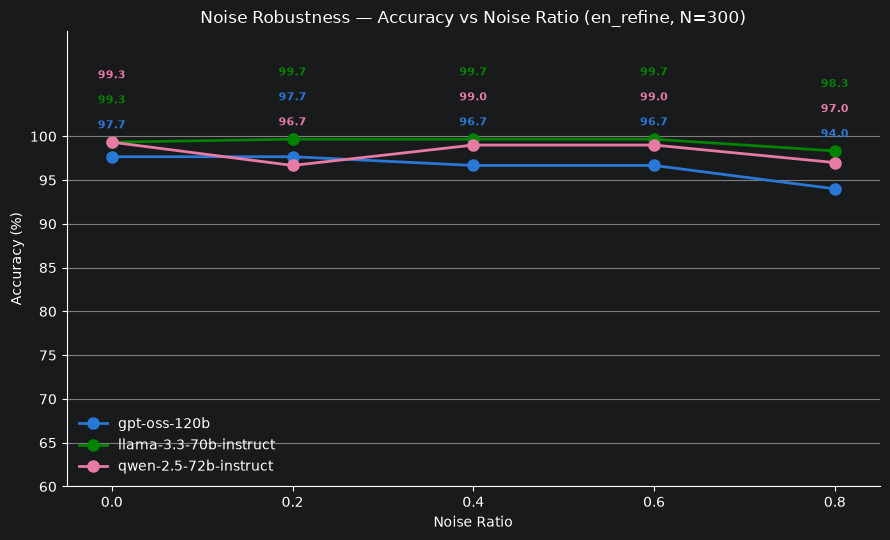

In [13]:
from reliablerag.rgb import plot_line_by_ratio

# Final, validated numbers (qwen row is the DeepInfra-pinned re-run above, which replaced the
# earlier OpenRouter-routing-contaminated numbers from the first run).
noise_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]
noise_robustness_results = {
    "openai/gpt-oss-120b": [97.67, 97.67, 96.67, 96.67, 94.00],
    "meta-llama/llama-3.3-70b-instruct": [99.33, 99.67, 99.67, 99.67, 98.33],
    "qwen/qwen-2.5-72b-instruct": [99.33, 96.67, 99.0, 99.0, 97.0],
}

plot_line_by_ratio(
    noise_robustness_results, noise_ratios,
    title="Noise Robustness — Accuracy vs Noise Ratio (en_refine, N=300)",
)

### 4. Ability B — Negative Rejection → Rejection rate (Table 3)

In [15]:
run_negative_rejection(llms, refine[:N_SAMPLES])

[reject] openai/gpt-oss-120b                    ... 25/300 records ( 114.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 50/300 records ( 242.8s elapsed)
[reject] openai/gpt-oss-120b                    ... 75/300 records ( 373.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 100/300 records ( 490.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 125/300 records ( 618.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 150/300 records ( 781.5s elapsed)
[reject] openai/gpt-oss-120b                    ... 175/300 records ( 930.3s elapsed)
[reject] openai/gpt-oss-120b                    ... 200/300 records (1038.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 225/300 records (1171.0s elapsed)
[reject] openai/gpt-oss-120b                    ... 250/300 records (1335.8s elapsed)
[reject] openai/gpt-oss-120b                    ... 275/300 records (1434.3s elapsed)
[reject] openai/gpt-oss-120b                    ... 300/3

,Rej %
openai/gpt-oss-120b,69.67
meta-llama/llama-3.3-70b-instruct,69.00
qwen/qwen-2.5-72b-instruct,76.67


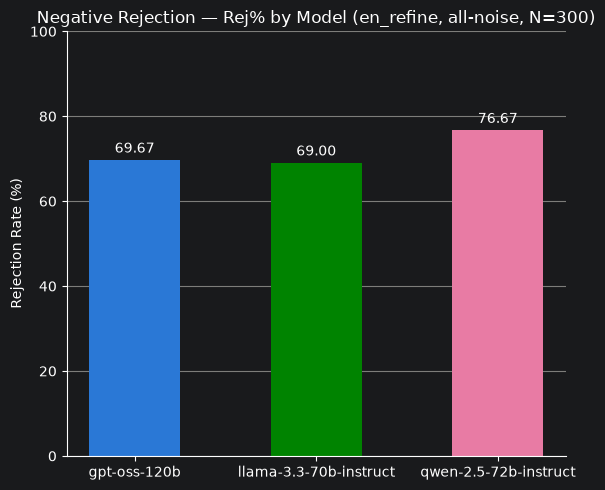

In [8]:
from reliablerag.rgb import plot_bar

negative_rejection_results = {
    "openai/gpt-oss-120b": 69.67,
    "meta-llama/llama-3.3-70b-instruct": 69.00,
    "qwen/qwen-2.5-72b-instruct": 76.67,
}

plot_bar(
    negative_rejection_results,
    title="Negative Rejection — Rej% by Model (en_refine, all-noise, N=300)",
    ylabel="Rejection Rate (%)",
)

### 5. Ability C — Information Integration → Accuracy (Table 5)

In [16]:
run_information_integration(llms, integ[:N_SAMPLES])

[integ]  openai/gpt-oss-120b                    ratio=0.0  ... 25/100 records ( 135.4s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.0  ... 50/100 records ( 310.2s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.0  ... 75/100 records ( 510.2s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.0  ... 100/100 records ( 643.9s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.0  acc= 75.00%  time= 643.9s
[integ]  openai/gpt-oss-120b                    ratio=0.2  ... 25/100 records ( 147.5s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.2  ... 50/100 records ( 408.4s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.2  ... 75/100 records ( 623.2s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.2  ... 100/100 records ( 767.6s elapsed)
[integ]  openai/gpt-oss-120b                    ratio=0.2  acc= 73.00%  time= 767.6s
[integ]  openai/gpt-oss-120b                    ratio=0.4  .

,noise=0.0,noise=0.2,noise=0.4
openai/gpt-oss-120b,75.0,73.0,68.0
meta-llama/llama-3.3-70b-instruct,83.0,85.0,76.0
qwen/qwen-2.5-72b-instruct,79.0,81.0,66.0


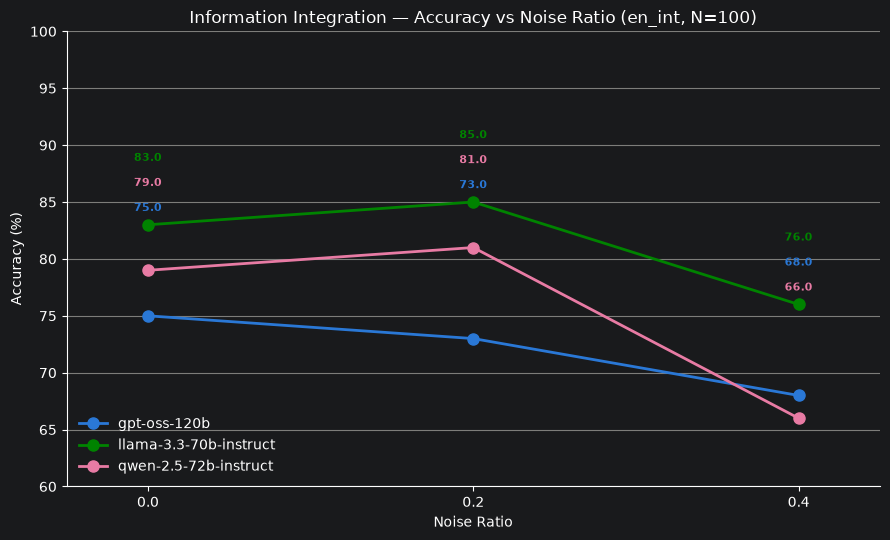

In [14]:
from reliablerag.rgb import plot_line_by_ratio

integration_ratios = [0.0, 0.2, 0.4]
information_integration_results = {
    "openai/gpt-oss-120b": [75.0, 73.0, 68.0],
    "meta-llama/llama-3.3-70b-instruct": [83.0, 85.0, 76.0],
    "qwen/qwen-2.5-72b-instruct": [79.0, 81.0, 66.0],
}

plot_line_by_ratio(
    information_integration_results, integration_ratios,
    title="Information Integration — Accuracy vs Noise Ratio (en_int, N=100)",
)

### 6. Ability D — Counterfactual Robustness → ACC / ACC_doc / ED / CR (Table 7)

In [24]:
run_counterfactual(llms, fact[:N_SAMPLES])

[fact]   openai/gpt-oss-120b                    ... 25/100 records ( 177.4s elapsed)
[fact]   openai/gpt-oss-120b                    ... 50/100 records ( 402.7s elapsed)
[fact]   openai/gpt-oss-120b                    ... 75/100 records ( 623.6s elapsed)
[fact]   openai/gpt-oss-120b                    ... 100/100 records ( 870.8s elapsed)
[fact]   openai/gpt-oss-120b                    {'ACC (correct_responses_count_without_docs)': 87.0, 'ACC_doc (correct_responses_count_with_poisoned_docs)': 51.0, 'ED (wrong_data_detected_with_poisoned_docs_count)': 57.0, 'CR (wrong_data_detected_and_corrected_with_poisoned_docs_count)': 89.47}  time= 870.8s
[fact]   meta-llama/llama-3.3-70b-instruct      ... 25/100 records (1659.2s elapsed)
[fact]   meta-llama/llama-3.3-70b-instruct      ... 50/100 records (2447.4s elapsed)
[fact]   meta-llama/llama-3.3-70b-instruct      ... 75/100 records (3438.7s elapsed)
[fact]   meta-llama/llama-3.3-70b-instruct      ... 100/100 records (4414.2s elapsed)
[fact]  

,ACC (correct_responses_count_without_docs),ACC_doc (correct_responses_count_with_poisoned_docs),ED (wrong_data_detected_with_poisoned_docs_count),CR (wrong_data_detected_and_corrected_with_poisoned_docs_count)
openai/gpt-oss-120b,87.0,51.0,57.0,89.47
meta-llama/llama-3.3-70b-instruct,90.0,65.0,60.0,93.33
qwen/qwen-2.5-72b-instruct,92.0,65.0,72.0,84.72


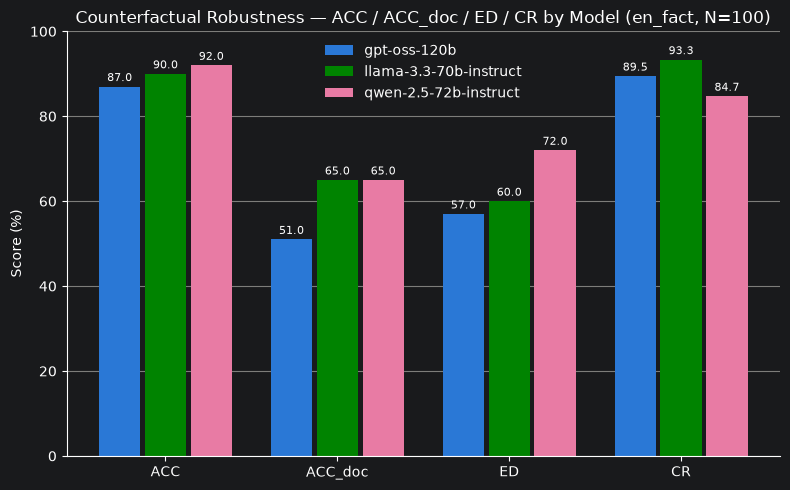

In [10]:
from reliablerag.rgb import plot_grouped_bar

counterfactual_metrics = ["ACC", "ACC_doc", "ED", "CR"]
counterfactual_results = {
    "openai/gpt-oss-120b": [87.0, 51.0, 57.0, 89.47],
    "meta-llama/llama-3.3-70b-instruct": [90.0, 65.0, 60.0, 93.33],
    "qwen/qwen-2.5-72b-instruct": [92.0, 65.0, 72.0, 84.72],
}

plot_grouped_bar(
    counterfactual_results, counterfactual_metrics,
    title="Counterfactual Robustness — ACC / ACC_doc / ED / CR by Model (en_fact, N=100)",
)